In [1]:
import os
import shutil
import random

def split_dataset(source_dir, output_dir, val_split=0.2):
    """
    Restructures:
      source_dir/class_name/*.jpg
    Into:
      output_dir/train/class_name/*.jpg
      output_dir/val/class_name/*.jpg
    """
    
    # Get all class names (subfolders in 'data')
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    
    if not classes:
        print(f"Error: No subfolders found in {source_dir}")
        return

    print(f"Found classes: {classes}")
    
    # Create the output structure
    for split in ['train', 'val']:
        for class_name in classes:
            os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

    # Move the files
    for class_name in classes:
        class_path = os.path.join(source_dir, class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Shuffle to ensure random split
        random.shuffle(images)
        
        # Calculate split index
        split_idx = int(len(images) * (1 - val_split))
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]
        
        print(f"Processing '{class_name}': {len(train_imgs)} train, {len(val_imgs)} val")
        
        # Copy files (Change shutil.copy to shutil.move if you want to delete originals)
        for img in train_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_dir, 'train', class_name, img)
            shutil.copy(src, dst)
            
        for img in val_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_dir, 'val', class_name, img)
            shutil.copy(src, dst)

    print("\nSuccess! Data is ready for training.")
    print(f"Location: {output_dir}/train and {output_dir}/val")

# --- CONFIGURATION ---
# Assuming your current folder is 'data' and you want to create a new folder 'dataset_processed'
# You can change 'dataset_processed' to whatever you want your final folder to be.
split_dataset(source_dir='data', output_dir='dataset_ready', val_split=0.2)

Found classes: ['classroom', 'living_room', 'office']
Processing 'classroom': 16764 train, 4191 val
Processing 'living_room': 32000 train, 8000 val
Processing 'office': 25644 train, 6411 val

Success! Data is ready for training.
Location: dataset_ready/train and dataset_ready/val


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import os
import urllib.request

def get_places365_resnet18(num_classes=3):
    # --- STEP 1: Initialize Model to Match the Checkpoint ---
    # We must tell ResNet to expect 365 classes initially, 
    # otherwise it defaults to 1000 and causes the size mismatch error.
    model = models.resnet18(num_classes=365) 
    
    # --- STEP 2: Download & Load Weights ---
    weight_url = 'http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar'
    weight_file = 'resnet18_places365.pth.tar'
    
    if not os.path.exists(weight_file):
        print(f"Downloading Places365 weights to {weight_file}...")
        urllib.request.urlretrieve(weight_url, weight_file)
    
    checkpoint = torch.load(weight_file, map_location=lambda storage, loc: storage)
    state_dict = checkpoint['state_dict']
    
    # Fix the 'module.' prefix issue (common in distributed training)
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '') 
        new_state_dict[name] = v
        
    # Load weights (This will now work because shapes match!)
    model.load_state_dict(new_state_dict, strict=True)
    print("Places365 weights loaded successfully.")
    
    # --- STEP 3: Modify for YOUR 3 Classes ---
    # Now that the pre-trained weights are loaded, we swap the head.
    # ResNet18's last layer is 'fc'.
    num_ftrs = model.fc.in_features # This is 512
    
    # Replace the 365-class layer with a 3-class layer
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

# Example Usage
model = get_places365_resnet18(num_classes=3)
print(model.fc) 
# Output should be: Linear(in_features=512, out_features=3, bias=True)

Places365 weights loaded successfully.
Linear(in_features=512, out_features=3, bias=True)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import urllib.request
from collections import OrderedDict
import time
import copy

# --- PART 1: MODEL LOADER (Fixed for 365 classes) ---
def get_places365_resnet18(num_classes=3):
    """
    Downloads ResNet18-Places365 weights and adapts them to 
    the target number of classes.
    """
    # 1. Initialize with 365 classes to match the pre-trained weights structure
    print("Initializing ResNet18 for Places365...")
    model = models.resnet18(num_classes=365)
    
    # 2. Download weights if needed
    weight_url = 'http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar'
    weight_file = 'resnet18_places365.pth.tar'
    
    if not os.path.exists(weight_file):
        print(f"Downloading weights to {weight_file}...")
        try:
            urllib.request.urlretrieve(weight_url, weight_file)
            print("Download complete.")
        except Exception as e:
            print(f"Error downloading weights: {e}")
            return None

    # 3. Load the state dictionary
    checkpoint = torch.load(weight_file, map_location=lambda storage, loc: storage)
    state_dict = checkpoint['state_dict']
    
    # 4. Fix Key Mismatch ('module.' prefix)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '') 
        new_state_dict[name] = v
        
    # 5. Load weights into the model
    model.load_state_dict(new_state_dict, strict=True)
    
    # 6. Freeze early layers (Transfer Learning)
    # This prevents us from destroying the scene-recognition capabilities
    for param in model.parameters():
        param.requires_grad = False
        
    # 7. Replace the final layer for YOUR classes
    # ResNet18's last layer is 'fc' with 512 inputs
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    # The new layer .fc has requires_grad=True by default, so it will train.
    print(f"Model adapted for {num_classes} classes.")
    return model

# --- PART 2: TRAINING PIPELINE ---
def train_model():
    # Configuration
    DATA_DIR = 'dataset_ready'  # Folder containing 'train' and 'val'
    MODEL_SAVE_PATH = 'places365_environment_model_new.pth'
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 50
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Data Transforms (Must match Places365 training logic)
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    # Load Data
    if not os.path.exists(DATA_DIR):
        print(f"Error: Directory '{DATA_DIR}' not found. Please check your data folder.")
        return

    image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                      for x in ['train', 'val']}
    
    dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
                   for x in ['train', 'val']}
    
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
    class_names = image_datasets['train'].classes
    
    print(f"Classes: {class_names}")
    print(f"Training images: {dataset_sizes['train']}, Validation images: {dataset_sizes['val']}")

    # Initialize Model
    model = get_places365_resnet18(num_classes=len(class_names))
    model = model.to(device)

    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    
    # We only optimize parameters that require gradients (the final layer)
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                          lr=LEARNING_RATE, momentum=0.9)
    
    # Decay LR by a factor of 0.1 every 7 epochs
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    # Training Loop
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(EPOCHS):
        print(f'\nEpoch {epoch+1}/{EPOCHS}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), MODEL_SAVE_PATH)
                print(f" -> New best model saved! (Acc: {best_acc:.4f})")

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

if __name__ == "__main__":
    train_model()

Using device: cpu
Classes: ['classroom', 'living_room', 'office']
Training images: 74408, Validation images: 18602
Initializing ResNet18 for Places365...
Model adapted for 3 classes.

Epoch 1/50
----------
train Loss: 0.4124 Acc: 0.8364
val Loss: 0.2545 Acc: 0.9030
 -> New best model saved! (Acc: 0.9030)

Epoch 2/50
----------
train Loss: 0.3672 Acc: 0.8519
val Loss: 0.2446 Acc: 0.9065
 -> New best model saved! (Acc: 0.9065)

Epoch 3/50
----------
train Loss: 0.3637 Acc: 0.8553
val Loss: 0.2393 Acc: 0.9088
 -> New best model saved! (Acc: 0.9088)

Epoch 4/50
----------
train Loss: 0.3610 Acc: 0.8552
val Loss: 0.2388 Acc: 0.9082

Epoch 5/50
----------
train Loss: 0.3578 Acc: 0.8575
val Loss: 0.2402 Acc: 0.9073

Epoch 6/50
----------
train Loss: 0.3541 Acc: 0.8579
val Loss: 0.2386 Acc: 0.9087

Epoch 7/50
----------
train Loss: 0.3582 Acc: 0.8586
val Loss: 0.2421 Acc: 0.9087

Epoch 8/50
----------
train Loss: 0.3507 Acc: 0.8599
val Loss: 0.2381 Acc: 0.9100
 -> New best model saved! (Acc: 0

Evaluating on: cpu
Classes: ['classroom', 'living_room', 'office']
Trained model weights loaded.
Running inference...

       EVALUATION REPORT

Classification Report:
              precision    recall  f1-score   support

   classroom       0.91      0.89      0.90      4191
 living_room       0.93      0.96      0.94      8000
      office       0.89      0.87      0.88      6411

    accuracy                           0.91     18602
   macro avg       0.91      0.91      0.91     18602
weighted avg       0.91      0.91      0.91     18602

Confusion Matrix:
[[3735   91  365]
 [  58 7651  291]
 [ 334  500 5577]]


<Figure size 800x600 with 0 Axes>

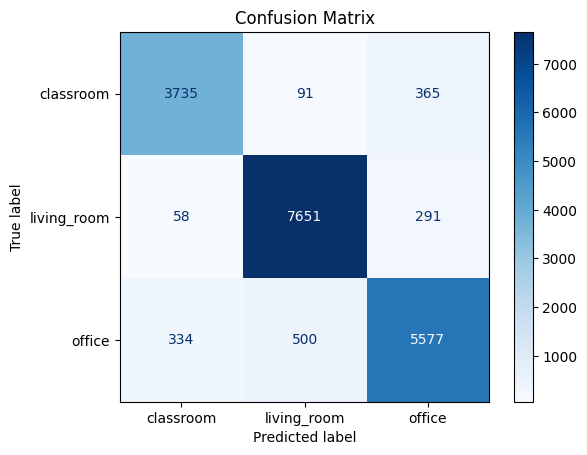

In [6]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import OrderedDict

# --- PART 1: MODEL ARCHITECTURE (MUST MATCH TRAINING) ---
def get_places365_resnet18(num_classes=3):
    # Initialize with 365 classes to match the pre-trained structure
    model = models.resnet18(num_classes=365)
    
    # We don't need to download weights again just to load our own .pth file,
    # but we DO need the structure to be identical so keys match.
    
    # Replace the final layer for YOUR classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

def evaluate_performance():
    # --- CONFIGURATION ---
    DATA_DIR = 'dataset_ready'  # Use your 'val' folder
    MODEL_PATH = 'places365_environment_model.pth'
    BATCH_SIZE = 32
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating on: {device}")

    # --- STEP 1: PREPARE DATA ---
    # Use the same transforms as 'val' during training
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load only the validation set
    val_dir = os.path.join(DATA_DIR, 'val')
    if not os.path.exists(val_dir):
        print(f"Error: {val_dir} not found!")
        return

    test_dataset = datasets.ImageFolder(val_dir, transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    class_names = test_dataset.classes
    print(f"Classes: {class_names}")

    # --- STEP 2: LOAD MODEL ---
    model = get_places365_resnet18(num_classes=len(class_names))
    
    # Load the trained weights
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print("Trained model weights loaded.")
    else:
        print(f"Error: {MODEL_PATH} not found.")
        return

    model = model.to(device)
    model.eval() # Set to evaluation mode (disables Dropout, Batch Norm updates)

    # --- STEP 3: RUN INFERENCE ---
    all_preds = []
    all_labels = []

    print("Running inference...")
    with torch.no_grad(): # Disable gradient calculation for speed
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- STEP 4: METRICS & REPORTING ---
    print("\n" + "="*30)
    print("       EVALUATION REPORT")
    print("="*30)

    # 1. Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:")
    print(cm)

    # 3. Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == "__main__":
    evaluate_performance()

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os

# --- 1. Define the Model Architecture (Must match training) ---
def load_trained_model(model_path, num_classes=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize with 365 classes first (to match structure)
    model = models.resnet18(num_classes=365)
    
    # Replace the head with your 3-class layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    # Load your trained weights
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at {model_path}")
        
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval() # Set to evaluation mode
    return model

# --- 2. The Prediction Function ---
def predict_environment(image_path, model, class_names):
    """
    Args:
        image_path (str): Path to the image file.
        model (torch.nn.Module): The loaded PyTorch model.
        class_names (list): List of class strings ['classroom', 'home', 'office'].
    
    Returns:
        str: Predicted class label.
        float: Confidence score (0.0 to 1.0).
    """
    device = next(model.parameters()).device
    
    # Define the standard transformation
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Load and preprocess image
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        return f"Error opening image: {e}", 0.0

    input_tensor = preprocess(image)
    
    # Add batch dimension (1, C, H, W)
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        output = model(input_batch)
        
        # Calculate probabilities using Softmax
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        
        # Get the winner
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_label = class_names[predicted_idx.item()]
    
    return predicted_label, confidence.item()

# --- 3. Example Usage ---
if __name__ == "__main__":
    # CONFIGURATION
    MODEL_PATH = 'places365_environment_model.pth'
    
    # IMPORTANT: These must be in alphabetical order of your folders!
    # If your folders were 'classroom', 'home', 'office', this list is correct.
    CLASS_NAMES = ['classroom', 'home', 'office'] 
    
    # Load model once
    try:
        model = load_trained_model(MODEL_PATH, num_classes=len(CLASS_NAMES))
        print("Model loaded successfully.")
        
        # Test on an image
        test_image = "test_image.jpg" # Replace with a real path
        
        if os.path.exists(test_image):
            label, conf = predict_environment(test_image, model, CLASS_NAMES)
            print(f"Prediction: {label} ({conf*100:.2f}%)")
        else:
            print(f"Please place an image named '{test_image}' to test.")
            
    except Exception as e:
        print(f"Error: {e}")

In [7]:
import cv2
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import os

# --- 1. Load Model (Same as before) ---
def load_model(model_path, num_classes=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet18(num_classes=365) # Initialize structure
    model.fc = nn.Linear(model.fc.in_features, num_classes) # Fix head
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

# --- 2. Process Video ---
def classify_video(video_path, model, class_names):
    device = next(model.parameters()).device
    
    # Standard Transform
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return "Error opening video", 0.0

    # We will sample 5 frames evenly spaced
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, 5, dtype=int)
    
    accumulated_probs = torch.zeros(len(class_names)).to(device)
    valid_frames = 0

    print(f"Scanning '{video_path}' ({total_frames} frames)...")

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        
        # Only process if this frame is one of our sample points
        if i in frame_indices:
            # 1. Convert BGR (OpenCV) to RGB (PIL)
            # This is the "JPG conversion" step happening in RAM
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(frame_rgb)
            
            # 2. Preprocess to Tensor
            input_tensor = preprocess(pil_image).unsqueeze(0).to(device)
            
            # 3. Inference
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.nn.functional.softmax(outputs[0], dim=0)
                accumulated_probs += probs
                valid_frames += 1

    cap.release()

    # --- 3. Average the Results ---
    if valid_frames == 0: return "No frames read", 0.0
    
    avg_probs = accumulated_probs / valid_frames
    confidence, predicted_idx = torch.max(avg_probs, 0)
    
    return class_names[predicted_idx.item()], confidence.item()

# --- Usage ---
if __name__ == "__main__":
    MODEL_PATH = 'places365_environment_model_new.pth'
    CLASSES = ['classroom', 'home', 'office'] # Must be alphabetical
    VIDEO_FILE = 'Data/Office-1.mp4' 
    
    # Create a dummy video file for testing if it doesn't exist? 
    # (No, user has one. Just ensure path is correct)

    if os.path.exists(MODEL_PATH) and os.path.exists(VIDEO_FILE):
        model = load_model(MODEL_PATH, len(CLASSES))
        label, conf = classify_video(VIDEO_FILE, model, CLASSES)
        print(f"\nFinal Classification: {label.upper()} ({conf*100:.1f}%)")
    else:
        print("Please check your model path and video file path.")

Scanning 'Data/Office-1.mp4' (1490 frames)...

Final Classification: OFFICE (89.8%)
